# Comparison of reskilling simulation runs
Felix Zaussinger | 21.11.2022

**Core Analysis Goal(s)**
1. Gather the data of all baseline simulations (1), with/ (2) without regional constraints to (a) optimally targeted reskilling and (b) random reskilling scenario.
2. Run this comparison for the three different viability thresholds (low, mid, high).
3. Compare the distributions and run tests on significant differences.

**Key Insight(s)**
1.
2.
3.

In [1]:
import copy
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils, plotting_utils, stats_utils
import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("notebook")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:,.2f}".format

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

from tqdm import tqdm

## Read data

Model setting combinations

In [2]:
job_pools = ["coal", "brown_techchange", "brown"]

# low (where does number come from?), percentile (q=0.96) and empirical (mean-sd at ISCO 4-digit) thresholds for transition viability
thresholds = ["viable-low"]  # ["low", "perc", "emp"]

regional_constraints = ["regC", "no-regC"]

reskilling_modes = [
    "baseline",
    "reskill-random",
    "reskill-coreWeight",
    "reskill-digital",
    # "coreness_percentile",
    "reskill-optimal",
]

Read raw data

In [3]:
# names
folder_name = "reskilling_final_thresh-{threshold}"
fmt_string = "{reskilling_mode}_wage-opt_{regional_constraint}_2019"

# iterate across all options
data_store = {}
for threshold in thresholds:
    for reskilling_mode in reskilling_modes:
        for regional_constraint in regional_constraints:
            fpath = os.path.join(
                useful_paths.figure_dir,
                folder_name.format(threshold=threshold),
                fmt_string.format(
                    reskilling_mode=reskilling_mode,
                    regional_constraint=regional_constraint,
                ),
                "{}.pkl".format(
                    fmt_string.format(
                        reskilling_mode=reskilling_mode,
                        regional_constraint=regional_constraint,
                    )
                ),
            )
            data_store[
                (threshold, reskilling_mode, regional_constraint)
            ] = pd.read_pickle(fpath)

## Preprocessing

Build up aggregated data cube of modelling results across all scenarios

In [4]:
aggdict = {
    "n_viable_transitions": np.mean,
    "earnings_delta_closest_switch_sum_mio": np.sum,
    "reskilling_mode": "first",
    "viability_threshold": "first",
    "regional_constraint": "first",
    "job_pool": "first",
}

keep_vars = [
    "n_viable_transitions",
    "earnings_delta_closest_switch_sum_mio",
    "NUTS_ID",
    "NACE1D",
    "COUNTRYW",
]

In [5]:
data_transformed_regions = []
data_transformed_sectors = []
for model_version in tqdm(list(data_store.keys())):
    # threshold - reskilling - regional constraint
    sub_dict = data_store[model_version]

    for job_pool in job_pools:
        # pool - country - DATA
        df_pool = pd.concat(list(sub_dict[job_pool].values()))

        # only keep select variables
        df_pool_sel = df_pool.loc[:, keep_vars]

        # add metadata of model run
        df_pool_sel["job_pool"] = job_pool
        df_pool_sel["viability_threshold"] = model_version[0]
        df_pool_sel["reskilling_mode"] = model_version[1]
        df_pool_sel["regional_constraint"] = model_version[2]

        # aggregate to regional level
        aggby = ["COUNTRYW", "NUTS_ID"]
        df_pool_sel_reg = df_pool_sel.groupby(aggby).agg(aggdict)
        data_transformed_regions.append(df_pool_sel_reg)

        # aggregate to sectoral level
        aggby = ["COUNTRYW", "NACE1D"]
        df_pool_sel_sec = df_pool_sel.groupby(aggby).agg(aggdict)
        data_transformed_sectors.append(df_pool_sel_sec)

100%|██████████| 10/10 [00:16<00:00,  1.67s/it]


Clean data set

In [6]:
# to df
df_regions = pd.concat(data_transformed_regions)
df_final_sectors = pd.concat(data_transformed_sectors)

results_dict_in = {
    "region_by_country": df_regions,
    "sector_by_country": df_final_sectors,
}
results_dict_out = {}

for version, df in results_dict_in.items():
    # make sure vars are numeric
    df["n_viable_transitions"] = df["n_viable_transitions"].astype(float)
    df["earnings_delta_closest_switch_sum_mio"] = df[
        "earnings_delta_closest_switch_sum_mio"
    ].astype(float)

    # rename job pools
    df = df.replace(
        {"job_pool": {"coal": "CPO", "brown_techchange": "FFPOTC", "brown": "FFPO"}}
    )

    # reset index
    df = df.reset_index()

    # make sure entries for countries with missing earnings data are coded as NaNs
    earnings_data_missing = ["AT", "ES", "CZ", "NO", "SE", "GR", "IS", "UK"]
    df.loc[
        df["COUNTRYW"].isin(earnings_data_missing),
        "earnings_delta_closest_switch_sum_mio",
    ] = np.nan

    # append
    results_dict_out[version] = df

In [7]:
df_regions = results_dict_out["region_by_country"]
df_sectors = results_dict_out["sector_by_country"]

In [8]:
from src.modelling.reskilling import ReskillingPathways

rp = ReskillingPathways()

In [9]:
df_sectors = pd.merge(df_sectors, rp.nace_labels, on="NACE1D", how="left")

## Visualisation

Statannotations settings

In [10]:
from statannotations.Annotator import Annotator

pairs = [
    # with regional constraints
    (("regC", "baseline"), ("regC", "reskill-optimal")),
    (("regC", "baseline"), ("regC", "reskill-random")),
    (("regC", "baseline"), ("regC", "reskill-coreWeight")),
    (("regC", "baseline"), ("regC", "reskill-digital")),
    # w/o regional constraints
    (("no-regC", "baseline"), ("no-regC", "reskill-optimal")),
    (("no-regC", "baseline"), ("no-regC", "reskill-random")),
    (("no-regC", "baseline"), ("no-regC", "reskill-coreWeight")),
    (("no-regC", "baseline"), ("no-regC", "reskill-digital")),
]

# annotate stats
pairs_regional_hue = [
    # with regional constraints
    (("baseline", "regC"), ("baseline", "no-regC")),
    (("reskill-random", "regC"), ("reskill-random", "no-regC")),
    (("reskill-coreWeight", "regC"), ("reskill-coreWeight", "no-regC")),
    (("reskill-digital", "regC"), ("reskill-digital", "no-regC")),
    (("reskill-optimal", "regC"), ("reskill-optimal", "no-regC")),
    # w/o regional constraints
]

##### Plotting parameters

In [11]:
alpha = 0.001
test = "Kruskal"
comparisons_correction = "Benjamini-Hochberg"
text_format = "simple"
loc = "inside"
show_test_name = False
verbose = False
palette = "BrBG"

In [12]:
# make country-level grouped stripplot
aggdict = {
    "n_viable_transitions": np.mean,
    "earnings_delta_closest_switch_sum_mio": np.sum,
    "viability_threshold": "first",
}

In [13]:
df_final_by_country = (
    df_regions.groupby(
        ["job_pool", "reskilling_mode", "regional_constraint", "COUNTRYW"]
    )
    .agg(aggdict)
    .reset_index()
)

df_final_by_sector = (
    df_sectors.groupby(["job_pool", "reskilling_mode", "regional_constraint", "NACE1D"])
    .agg(aggdict)
    .reset_index()
)

#### Transition numbers

##### Regional

Boxplot

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


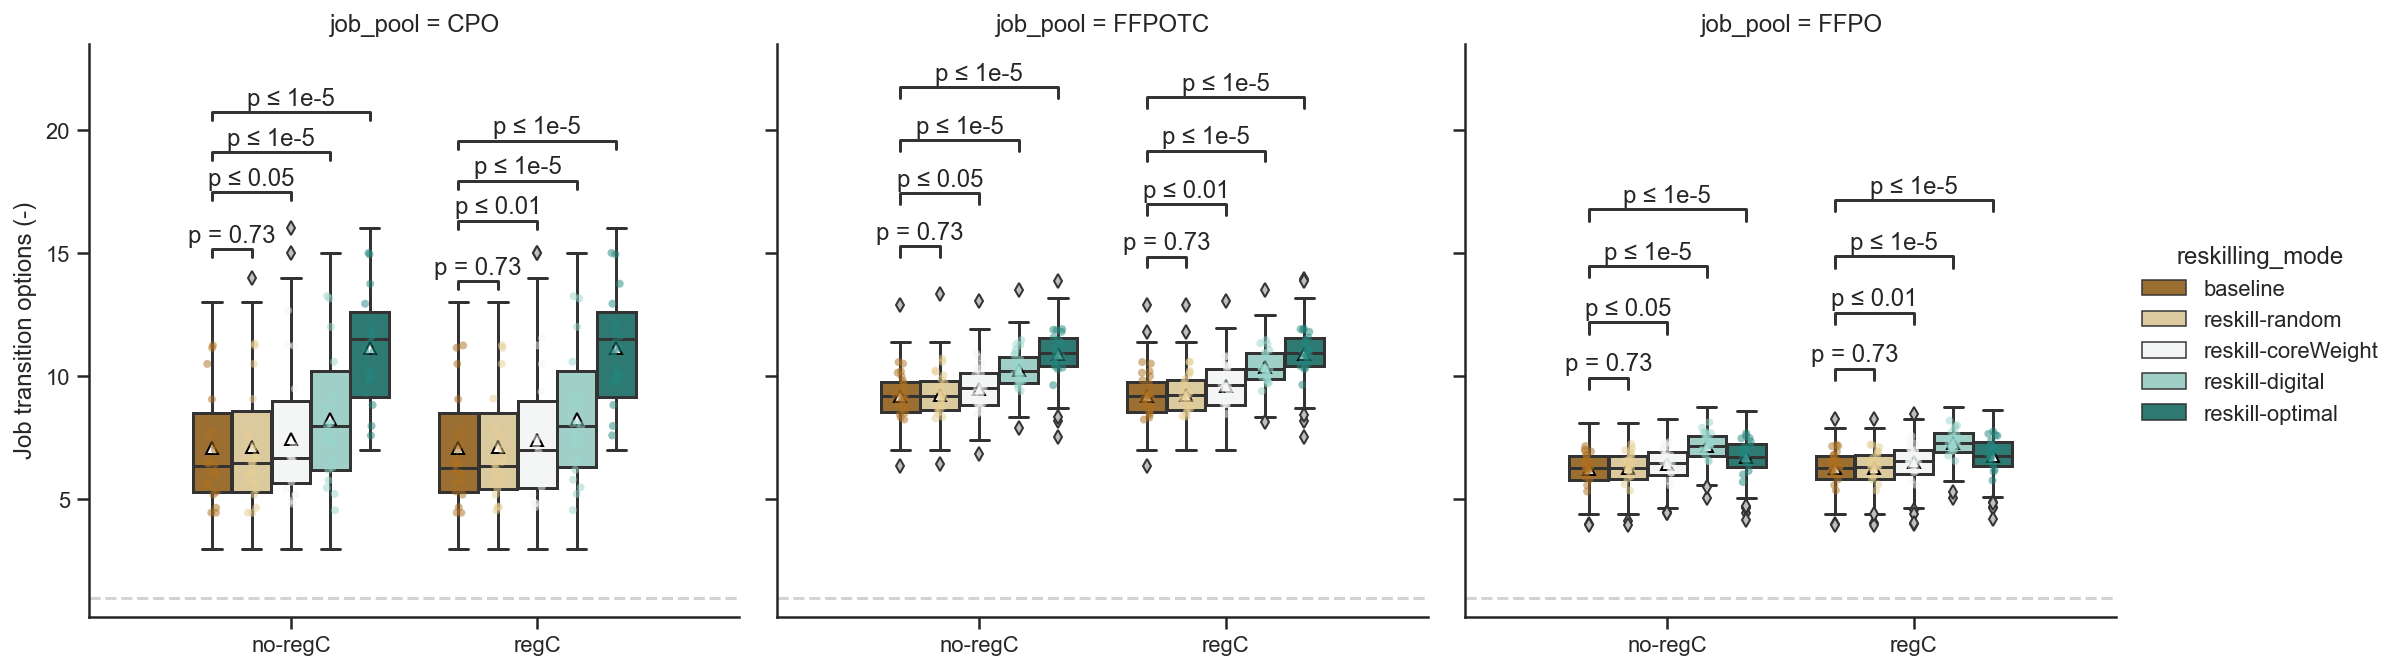

In [14]:
x = "regional_constraint"
y = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = [
    "baseline",
    "reskill-random",
    "reskill-coreWeight",
    "reskill-digital",
    "reskill-optimal",
]
order = ["no-regC", "regC"]
sharey = True
kind = "box"

# boxplots
g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette=palette,
)

# annotate stats
axes = g.axes.flatten()
for i, ax in enumerate(axes):

    # country-level stripplot
    sns.stripplot(
        x=x,
        y=y,
        data=df_final_by_country.loc[df_final_by_country["job_pool"] == col_order[i]],
        order=order,
        hue_order=hue_order,
        hue=hue,
        dodge=True,
        marker="o",
        size=4,
        edgecolor="black",
        palette=palette,
        alpha=0.5,
        ax=ax,
    )
    ax.legend([], [], frameon=False)

    # # country-level scatterplot
    # sns.scatterplot(
    #     x=hue,
    #     y=y,
    #     data=df_final_by_country.loc[df_final_by_country["job_pool"] == col_order[i]].dropna(subset=["COUNTRYW"]),
    #     style="COUNTRYW",
    #     hue="COUNTRYW",
    #     marker='o',
    #     size=4,
    #     edgecolor="black",
    #     palette="Paired",
    #     alpha=0.5,
    #     ax=ax,
    # )

    # styling
    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(
        ax,
        pairs,
        data=df_regions,
        x=x,
        y=y,
        order=order,
        hue=hue,
    )
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [15]:
df_final_by_country.query(
    "(job_pool=='CPO') & (reskilling_mode=='baseline') & (regional_constraint=='no-regC')"
)

,job_pool,reskilling_mode,regional_constraint,COUNTRYW,n_viable_transitions,earnings_delta_closest_switch_sum_mio,viability_threshold
0,CPO,baseline,no-regC,AT,6.45,0.00,viable-low
1,CPO,baseline,no-regC,BE,11.25,17.44,viable-low
2,CPO,baseline,no-regC,CH,11.15,23.14,viable-low
3,CPO,baseline,no-regC,CZ,7.02,0.00,viable-low
4,CPO,baseline,no-regC,DE,9.07,99.55,viable-low
5,CPO,baseline,no-regC,DK,6.12,-8.22,viable-low
6,CPO,baseline,no-regC,ES,5.55,0.00,viable-low
7,CPO,baseline,no-regC,FI,5.20,26.34,viable-low
8,CPO,baseline,no-regC,FR,7.57,-91.29,viable-low
9,CPO,baseline,no-regC,GR,5.31,0.00,viable-low


C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


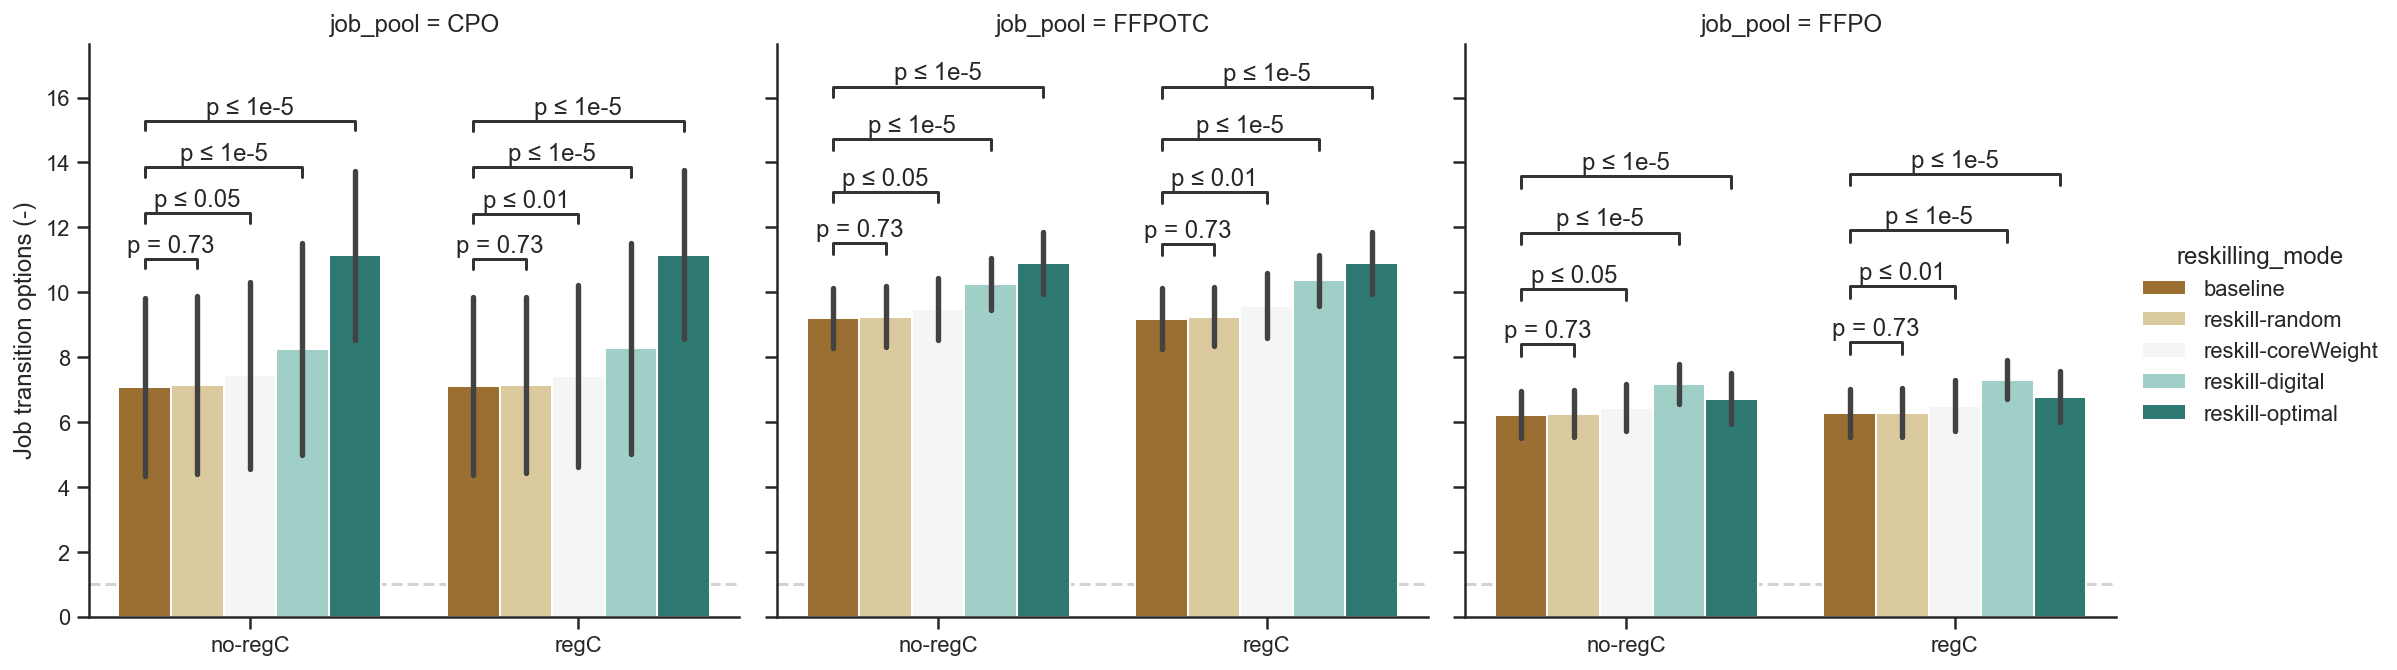

In [16]:
x = "regional_constraint"
y = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = True
kind = "bar"

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    kind=kind,
    sharey=sharey,
    estimator=np.mean,
    ci="sd",
    height=5,
    aspect=1,
    palette="BrBG",
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:

    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(ax, pairs, data=df_regions, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

Hue = regional constraint

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


Text(18.66218333333333, 0.5, 'Job transition options (-)')

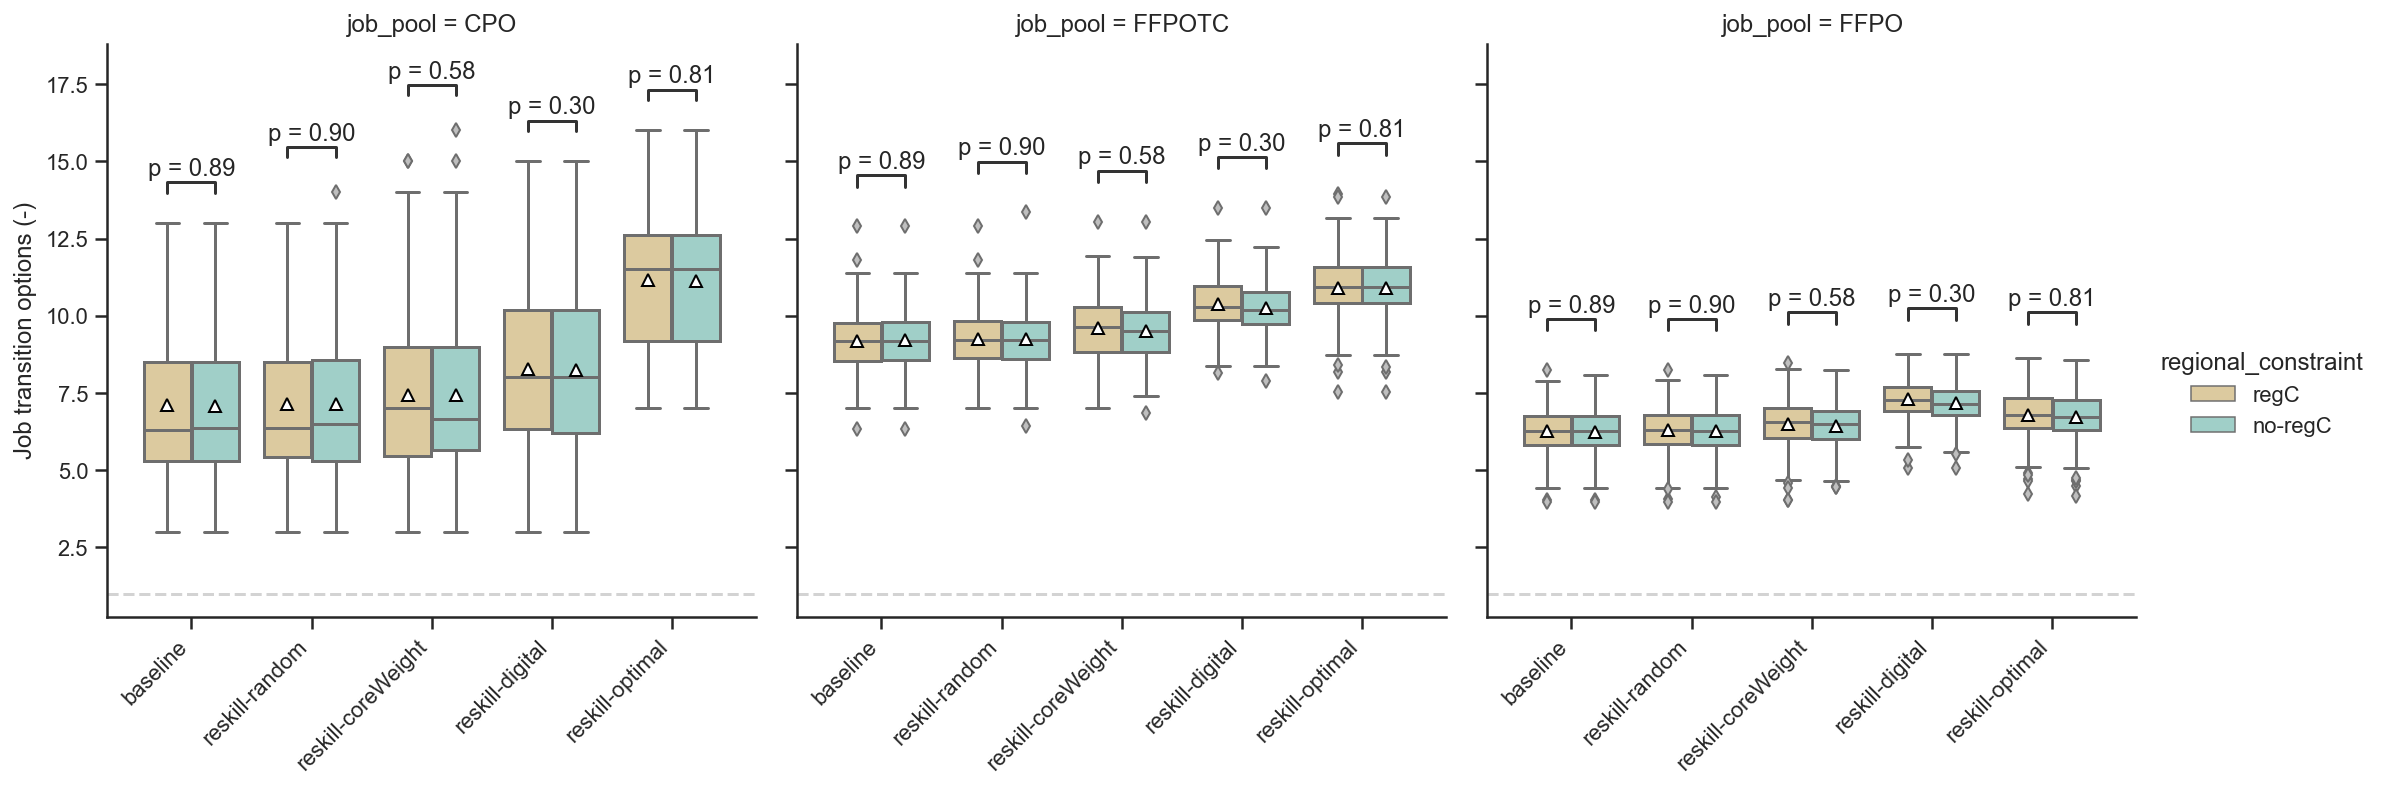

In [17]:
x = "reskilling_mode"
y = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "regional_constraint"
col = "job_pool"
# order = ["no-regC", "regC"]
sharey = True

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    hue=hue,
    # order=order,
    kind="box",
    sharey=sharey,
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    palette="BrBG",
)

axes = g.axes.flatten()
for ax in axes:
    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(ax, pairs_regional_hue, data=df_regions, x=x, y=y, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

##### Sectors

In [18]:
sectors = [
    "Manufacturing",
    "Construction",
    "Electricity, Gas",
    "Agri., Forest., Fish.",
    "Mining",
    "Water, Waste Mgmt.",
    "Trade, Repair",
    "Transport",
]

pairs_sectors = []
for sector in sectors:
    # with regional constraints
    pair = ((sector, "baseline"), (sector, "reskill-optimal"))
    pairs_sectors.append(pair)

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


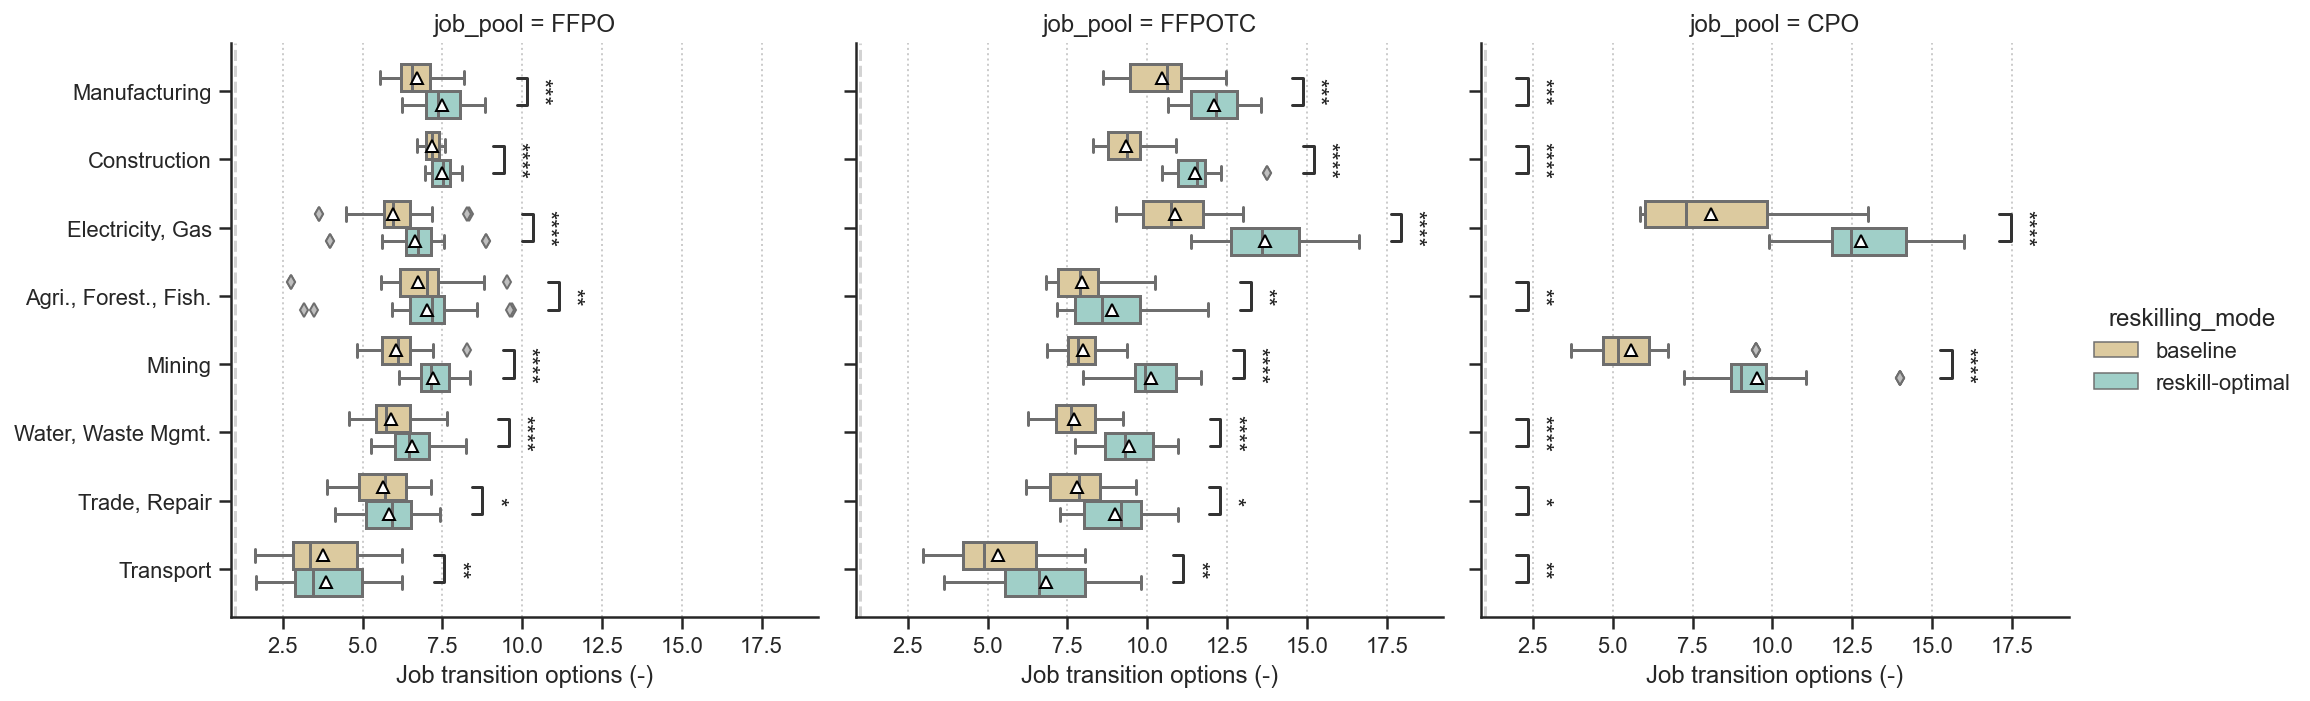

In [19]:
reskilling_modes = ["baseline", "reskill-optimal"]
df = df_sectors.loc[
    df_sectors["paper_selection"] & df_sectors["reskilling_mode"].isin(reskilling_modes)
]

y = "NACE1D_label_short"
x = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"

order = [
    "Manufacturing",
    "Construction",
    "Electricity, Gas",
    "Agri., Forest., Fish.",
    "Mining",
    "Water, Waste Mgmt.",
    "Trade, Repair",
    "Transport",
]
col_order = ["FFPO", "FFPOTC", "CPO"]
hue_order = [
    "baseline",
    "reskill-optimal",
]

sharey = True
kind = "box"

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette=palette,
)

# annotate stats
axes = g.axes.flatten()
for i, ax in enumerate(axes):

    # styling
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_ylabel(None)
    ax.set_xlabel("Job transition options (-)")

    # test statistic
    annotator = Annotator(
        ax=ax, pairs=pairs_sectors, data=df, x=x, y=y, order=order, hue=hue, orient="h"
    )
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format="star",
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_by_sector_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [20]:
axes

array([<AxesSubplot:title={'center':'job_pool = FFPO'}, xlabel='Job transition options (-)'>,
       <AxesSubplot:title={'center':'job_pool = FFPOTC'}, xlabel='Job transition options (-)'>,
       <AxesSubplot:title={'center':'job_pool = CPO'}, xlabel='Job transition options (-)'>],
      dtype=object)

#### Income changes

John Tukey, who was a driving force in the development of exploratory data analysis, defined outliers as points more than 1.5 x IQR. Recall that IQR is the inter-quartile range, which captures 50% of the data points in a data set.

[https://neuraldatascience.io/5-eda/data_cleaning.html]()


##### Regions

Hue = reskilling mode

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


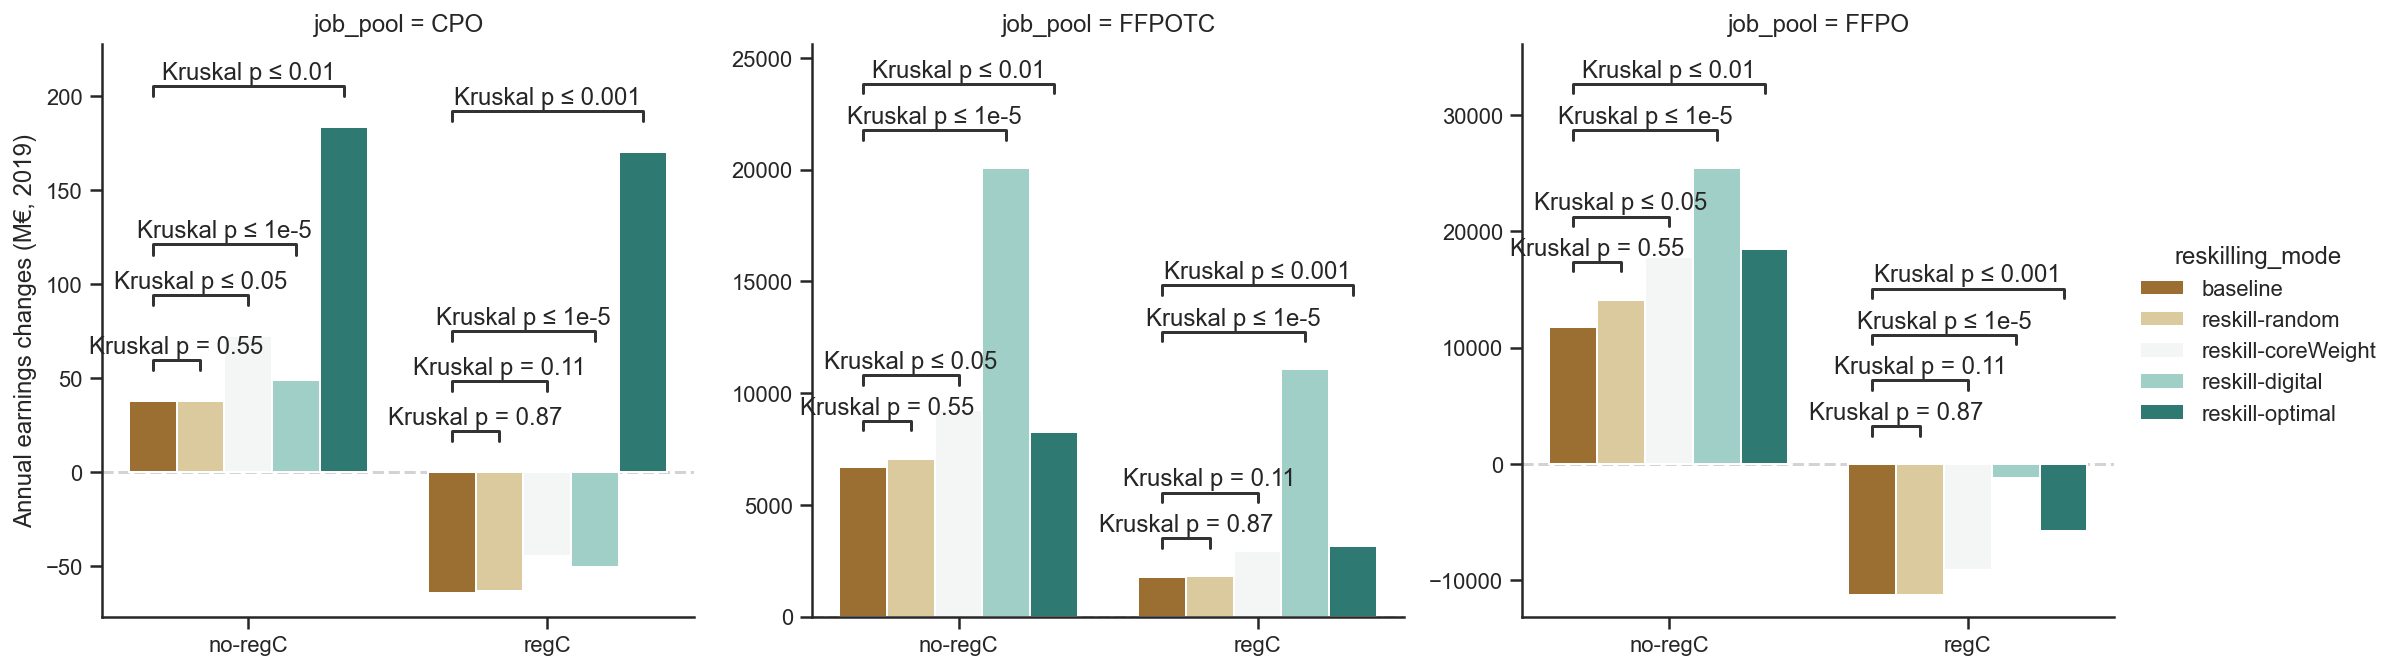

In [21]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "bar"

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    estimator=np.sum,
    height=5,
    aspect=1,
    ci=None,
    palette="BrBG"
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black")
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(ax, pairs, data=df_regions, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=True,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}_sum.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


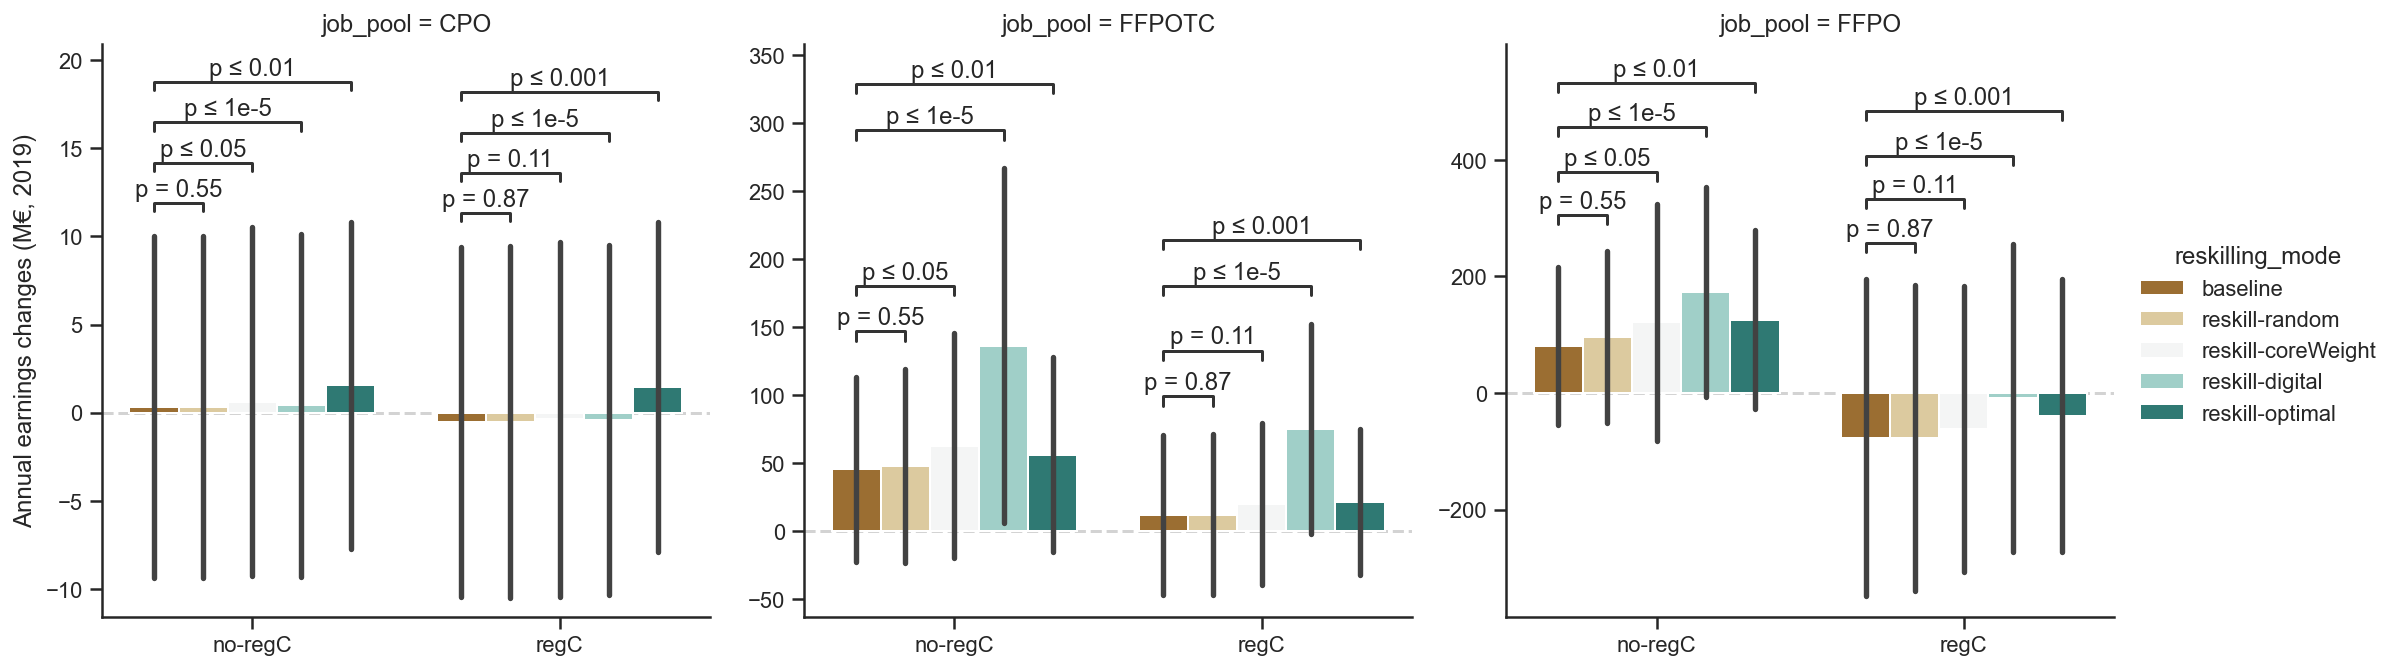

In [22]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "bar"

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    estimator=np.mean,
    height=5,
    aspect=1,
    ci="sd",
    palette="BrBG"
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black")
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(ax, pairs, data=df_regions, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}_mean.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


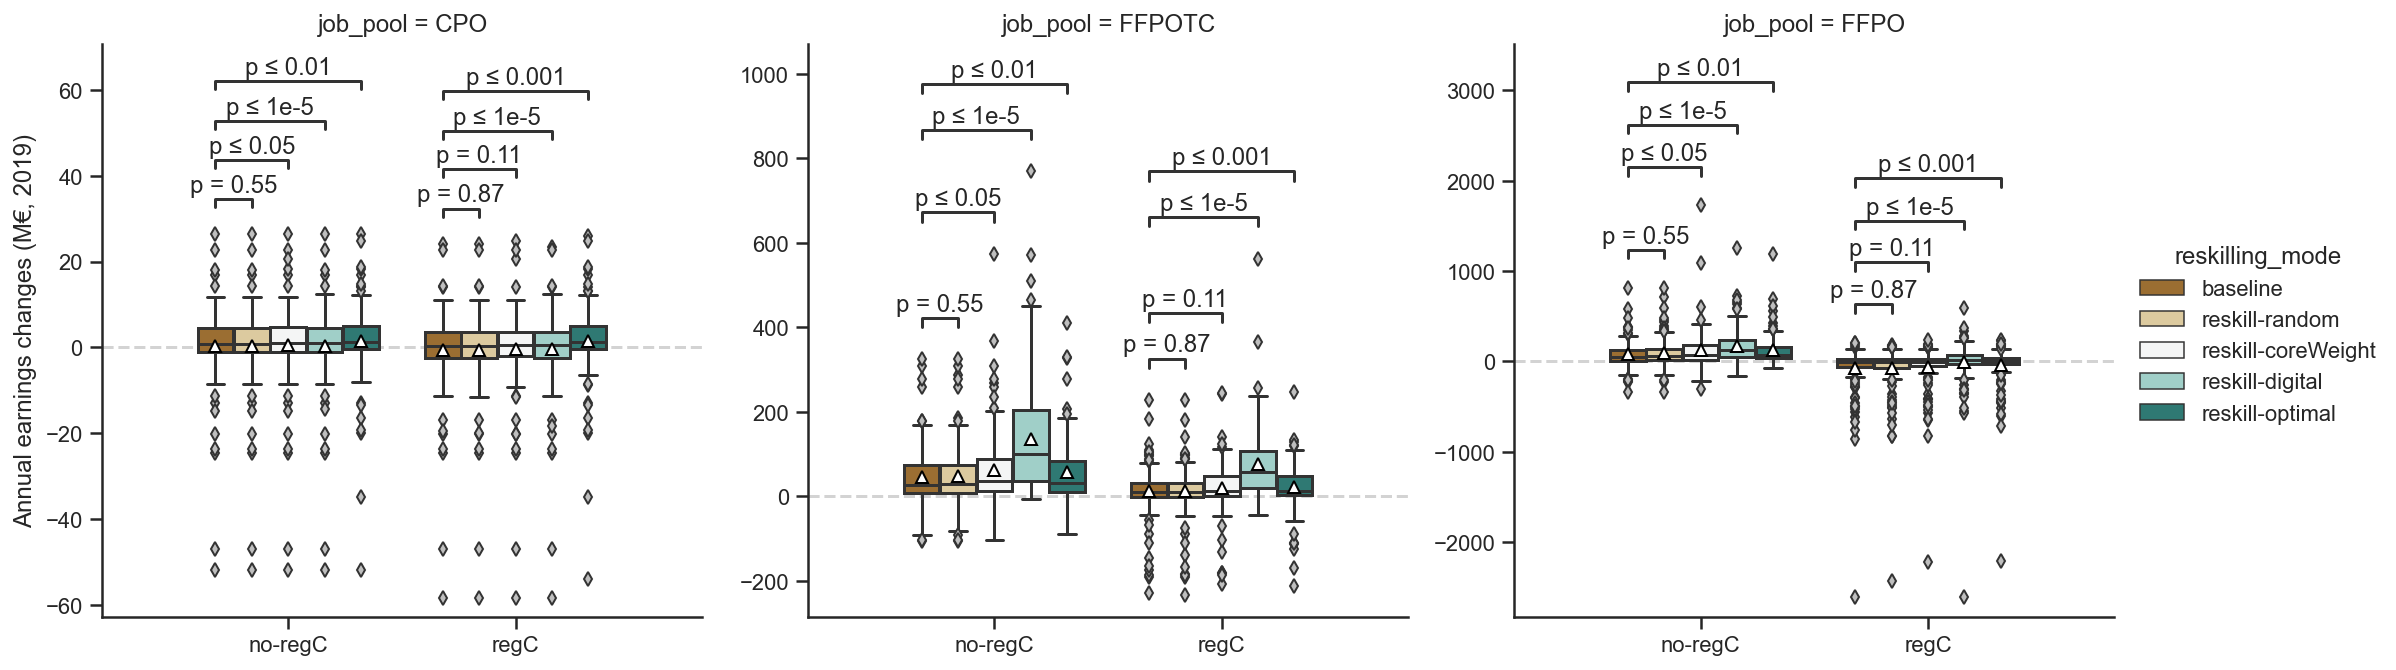

In [23]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "box"

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    height=5,
    aspect=1,
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    palette="BrBG",
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(ax, pairs, data=df_regions, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

##### Sectors

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


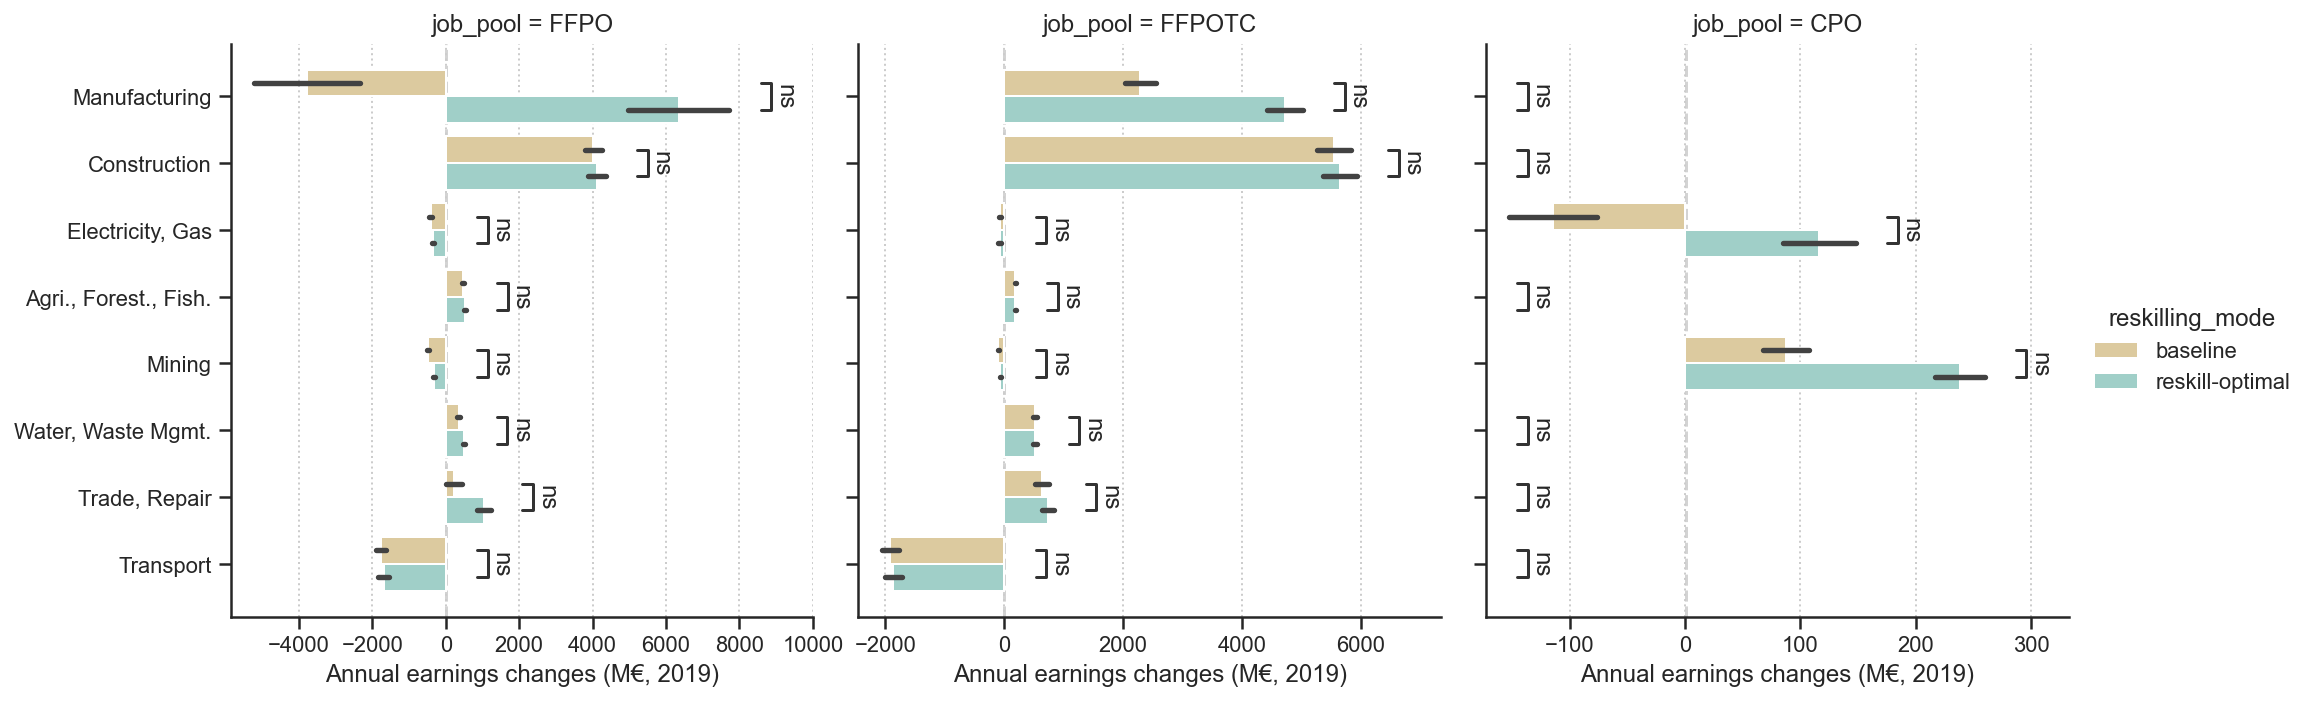

In [24]:
reskilling_modes = ["baseline", "reskill-optimal"]
df = df_sectors.loc[
    df_sectors["paper_selection"] & df_sectors["reskilling_mode"].isin(reskilling_modes)
]

y = "NACE1D_label_short"
x = "earnings_delta_closest_switch_sum_mio"  # n_viable_transitions / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"

order = [
    "Manufacturing",
    "Construction",
    "Electricity, Gas",
    "Agri., Forest., Fish.",
    "Mining",
    "Water, Waste Mgmt.",
    "Trade, Repair",
    "Transport",
]
col_order = ["FFPO", "FFPOTC", "CPO"]
hue_order = [
    "baseline",
    "reskill-optimal",
]

sharey = True
sharex = False
kind = "bar"

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    estimator=np.sum,
    ci="sd",
    # flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette=palette,
)

# annotate stats
axes = g.axes.flatten()
for i, ax in enumerate(axes):

    # styling
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_ylabel(None)
    ax.set_xlabel("Annual earnings changes (M€, 2019)")

    # test statistic
    annotator = Annotator(
        ax=ax, pairs=pairs_sectors, data=df, x=x, y=y, order=order, hue=hue, orient="h"
    )
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format="star",
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_income_by_sector_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

#### Results by country

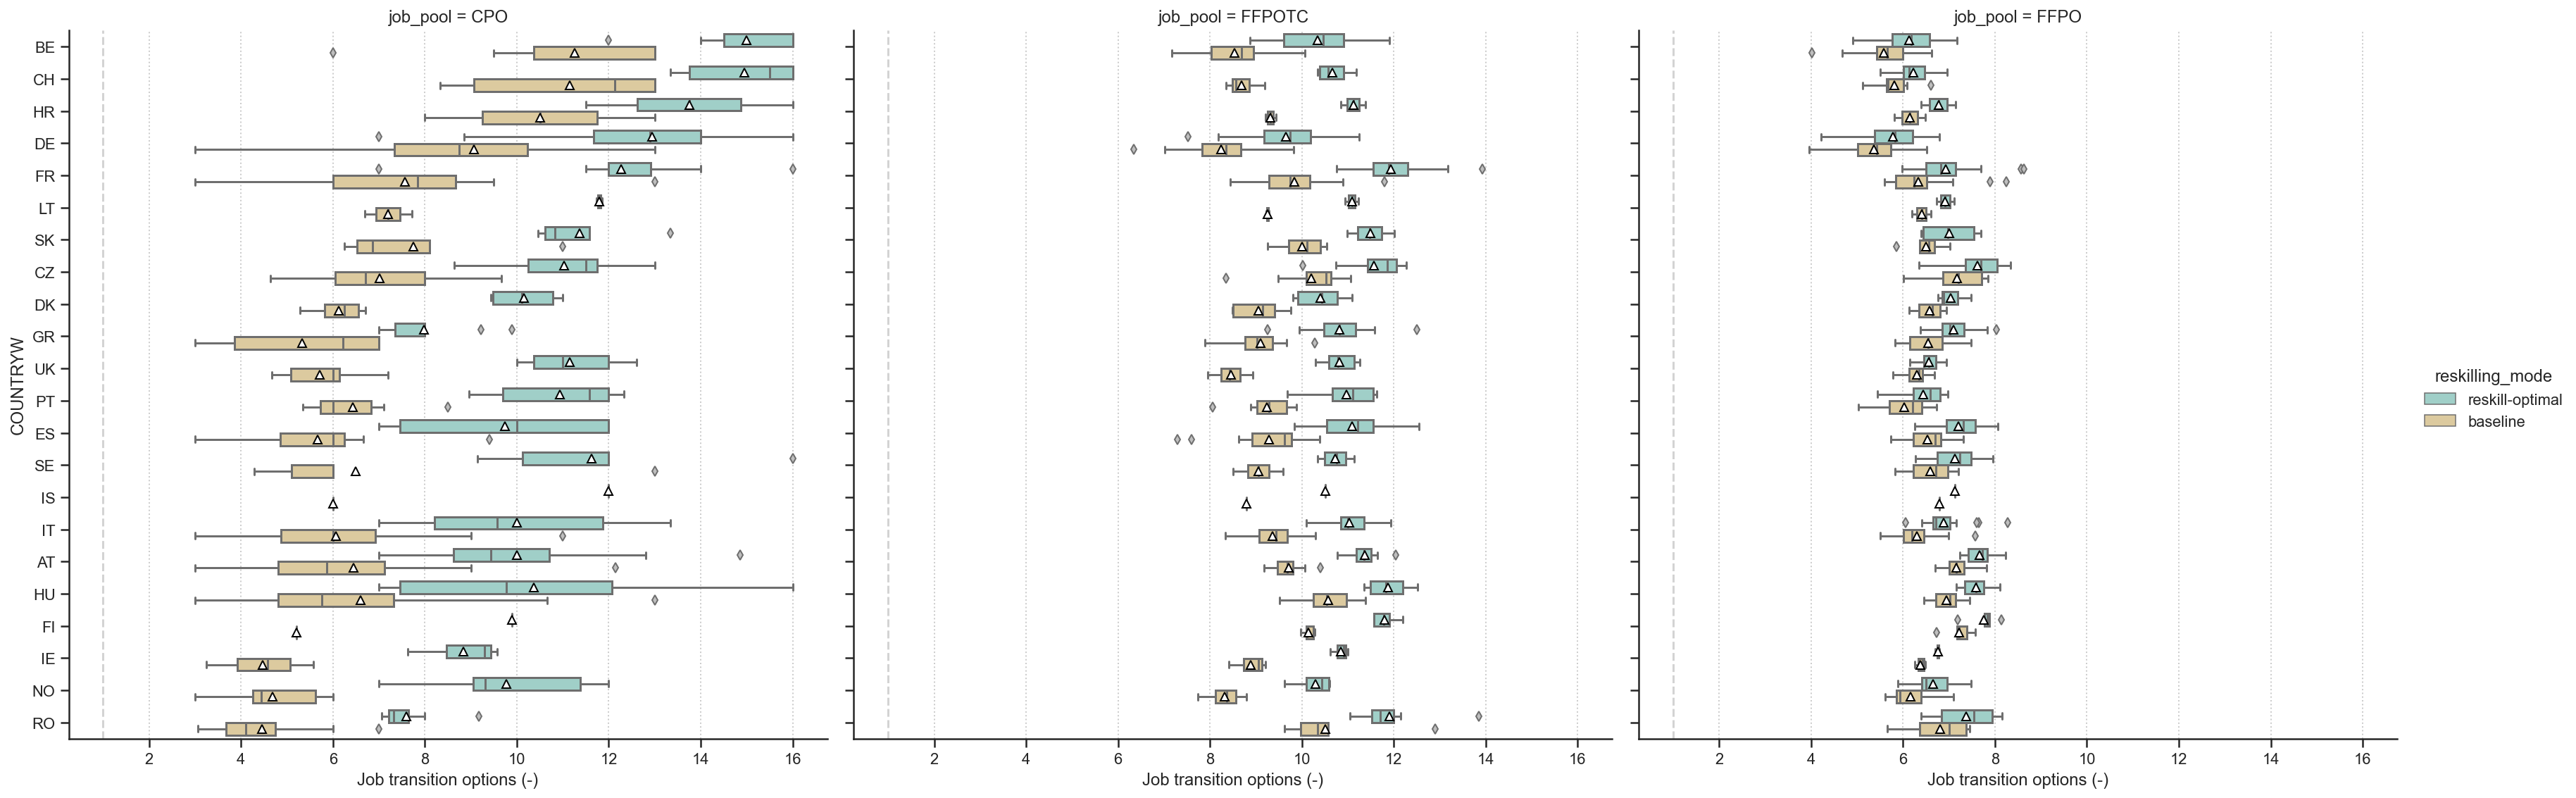

In [25]:
y = "COUNTRYW"
x = "n_viable_transitions"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = ["reskill-optimal", "baseline"]
sharey = True
sharex = True
kind = "box"
palette = "BrBG_r"

# make country-level grouped stripplot
aggdict = {
    "n_viable_transitions": np.median,
    "earnings_delta_closest_switch_sum_mio": np.mean,
    "viability_threshold": "first",
}

df = df_regions.loc[
    (df_regions["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_regions["regional_constraint"] == "regC")
]
order = (
    df.loc[
        (
            df_regions["reskilling_mode"].isin(["baseline"])
            & (df_regions["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=False)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=8,
    aspect=1,
    palette=palette,
)

# annotate vline
axes = g.axes.flatten()
for ax in axes:
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Job transition options (-)")  # "Annual earnings changes (M€, 2019)"

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

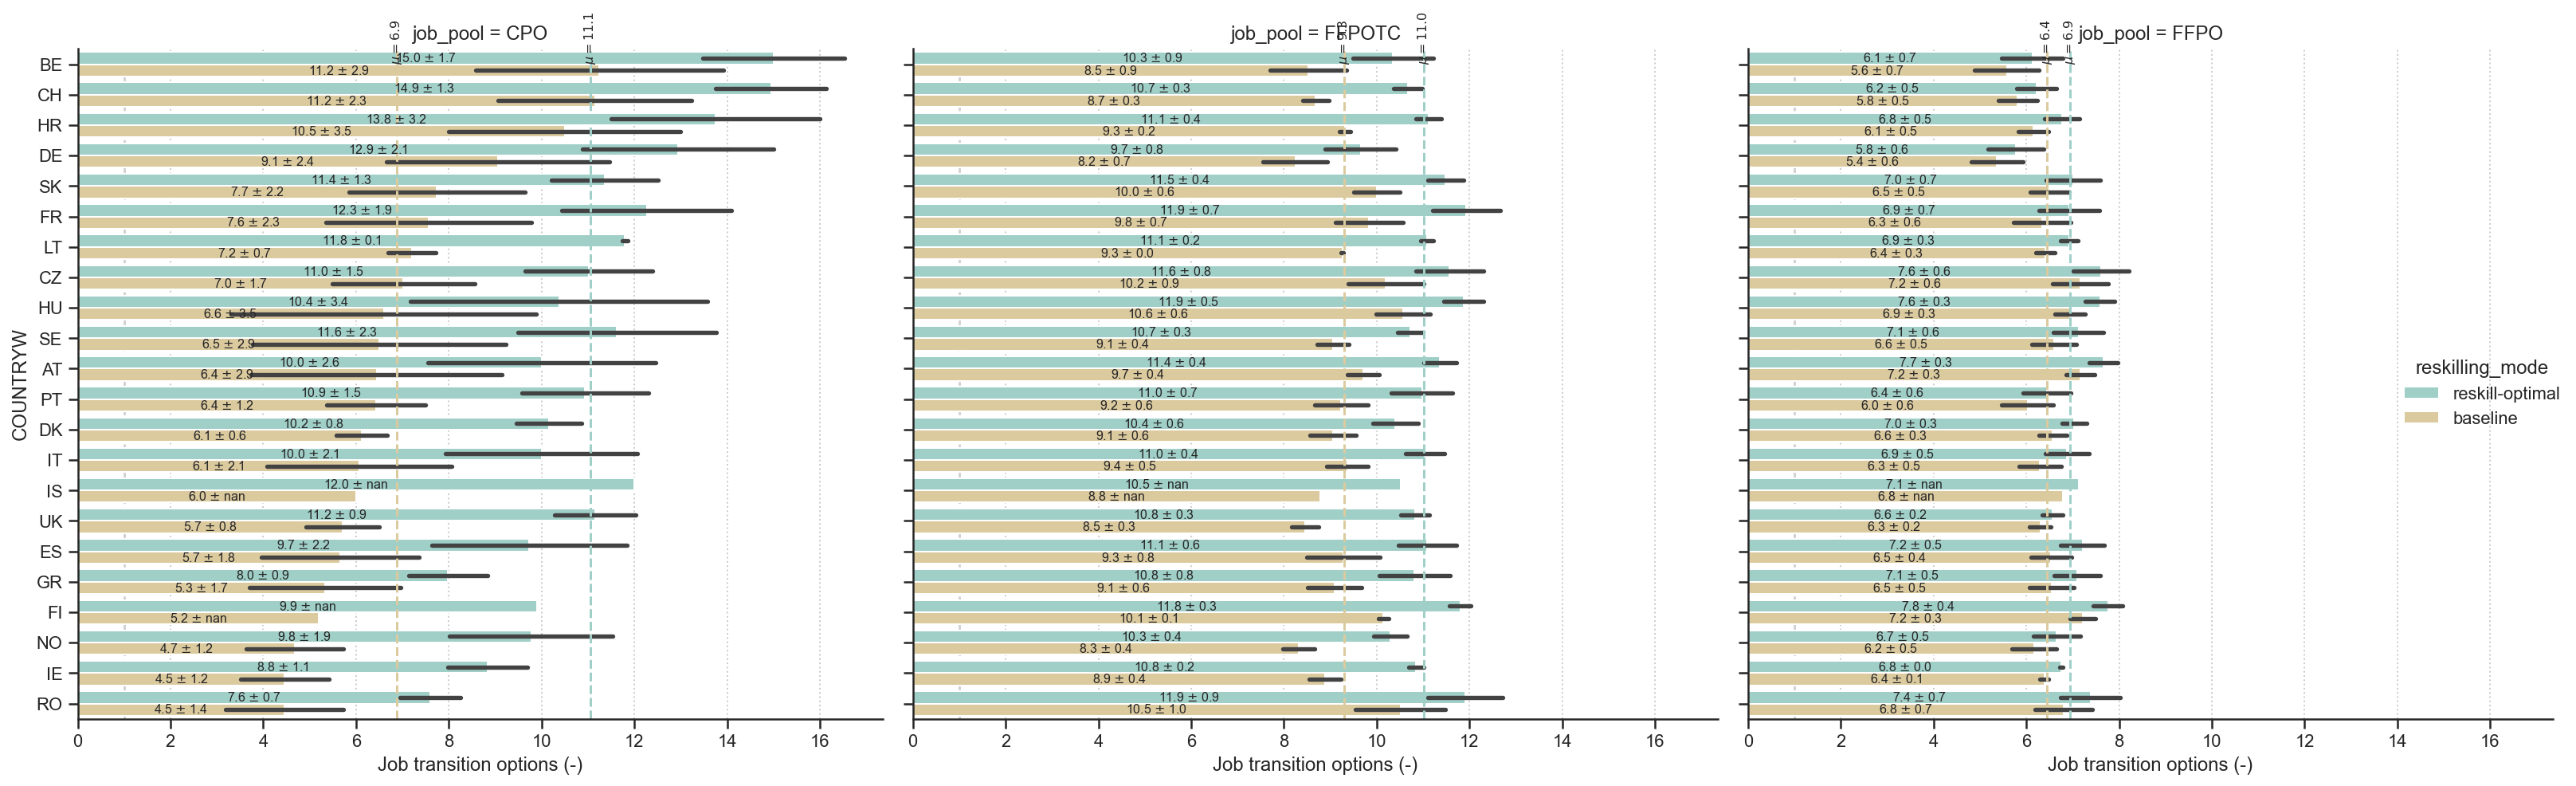

In [26]:
y = "COUNTRYW"
x = "n_viable_transitions"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = ["reskill-optimal", "baseline"]
sharey = True
sharex = True
kind = "bar"
palette = "BrBG_r"

# make country-level grouped stripplot
aggdict = {
    "n_viable_transitions": np.mean,
    "earnings_delta_closest_switch_sum_mio": np.mean,
    "viability_threshold": "first",
}

df = df_regions.loc[
    (df_regions["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_regions["regional_constraint"] == "regC")
]
order = (
    df.loc[
        (
            df_regions["reskilling_mode"].isin(["baseline"])
            & (df_regions["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=False)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    ci="sd",
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=7,
    aspect=1,
    palette=palette,
)

aggdict = {
    "n_viable_transitions": [np.mean, np.std],
    "earnings_delta_closest_switch_sum_mio": np.mean,
    "viability_threshold": "first",
}
df_annot = df.groupby(["job_pool", "COUNTRYW", "reskilling_mode"]).agg(aggdict)
df_annot.columns = ["_".join(col) for col in df_annot.columns]
df_annot = df_annot.reindex(order, level=1).reset_index()

# annotate vline
axes = g.axes.flatten()
for i, ax in enumerate(axes):
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Job transition options (-)")  # "Annual earnings changes (M€, 2019)"

    # annotate numbers (one container per hue level)
    for container in ax.containers:
        df_hue = df_annot.loc[
            (df_annot[hue] == container.get_label())
            & (df_annot["job_pool"] == col_order[i])
        ]
        labels = (
            df_hue.loc[:, "n_viable_transitions_mean"].round(1).astype(str)
            + r" $\pm$ "
            + df_hue.loc[:, "n_viable_transitions_std"].round(1).astype(str)
        )
        ax.bar_label(container, labels=labels, fontsize=8, label_type="center")

        # annotate mean
        x = df_hue["n_viable_transitions_mean"].mean()
        c = container[-1].get_facecolor()
        ax.axvline(x, linestyle="--", color=c, label=r"$\mu$")  # , zorder=0)

        ax.text(
            x,
            0,
            "$\mu = {:.1f}$".format(x),
            rotation=90,
            va="bottom",
            ha="center",
            fontsize=8,
        )

# save
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [27]:
ax.containers[0][-1].get_facecolor()

(0.6256535947712419, 0.8109477124183008, 0.7825163398692812, 1.0)

In [28]:
df_hue

,job_pool,COUNTRYW,reskilling_mode,n_viable_transitions_mean,n_viable_transitions_std,earnings_delta_closest_switch_sum_mio_mean,viability_threshold_first
44,FFPO,BE,baseline,5.58,0.73,-18.58,viable-low
46,FFPO,CH,baseline,5.82,0.46,12.86,viable-low
48,FFPO,HR,baseline,6.15,0.47,14.26,viable-low
50,FFPO,DE,baseline,5.37,0.57,-189.63,viable-low
52,FFPO,SK,baseline,6.50,0.48,-60.84,viable-low
54,FFPO,FR,baseline,6.34,0.64,57.88,viable-low
56,FFPO,LT,baseline,6.40,0.29,-19.51,viable-low
58,FFPO,CZ,baseline,7.17,0.64,NaN,viable-low
60,FFPO,HU,baseline,6.94,0.35,-30.25,viable-low
62,FFPO,SE,baseline,6.59,0.52,NaN,viable-low


In [29]:
df_annot

,job_pool,COUNTRYW,reskilling_mode,n_viable_transitions_mean,n_viable_transitions_std,earnings_delta_closest_switch_sum_mio_mean,viability_threshold_first
0,CPO,BE,baseline,11.25,2.93,2.91,viable-low
1,CPO,BE,reskill-optimal,15.00,1.67,4.09,viable-low
2,CPO,CH,baseline,11.15,2.29,3.86,viable-low
3,CPO,CH,reskill-optimal,14.94,1.31,4.96,viable-low
4,CPO,HR,baseline,10.50,3.54,0.89,viable-low
...,...,...,...,...,...,...,...
127,FFPOTC,NO,reskill-optimal,10.29,0.38,NaN,viable-low
128,FFPOTC,IE,baseline,8.89,0.42,45.45,viable-low
129,FFPOTC,IE,reskill-optimal,10.85,0.20,67.53,viable-low
130,FFPOTC,RO,baseline,10.51,1.03,0.37,viable-low


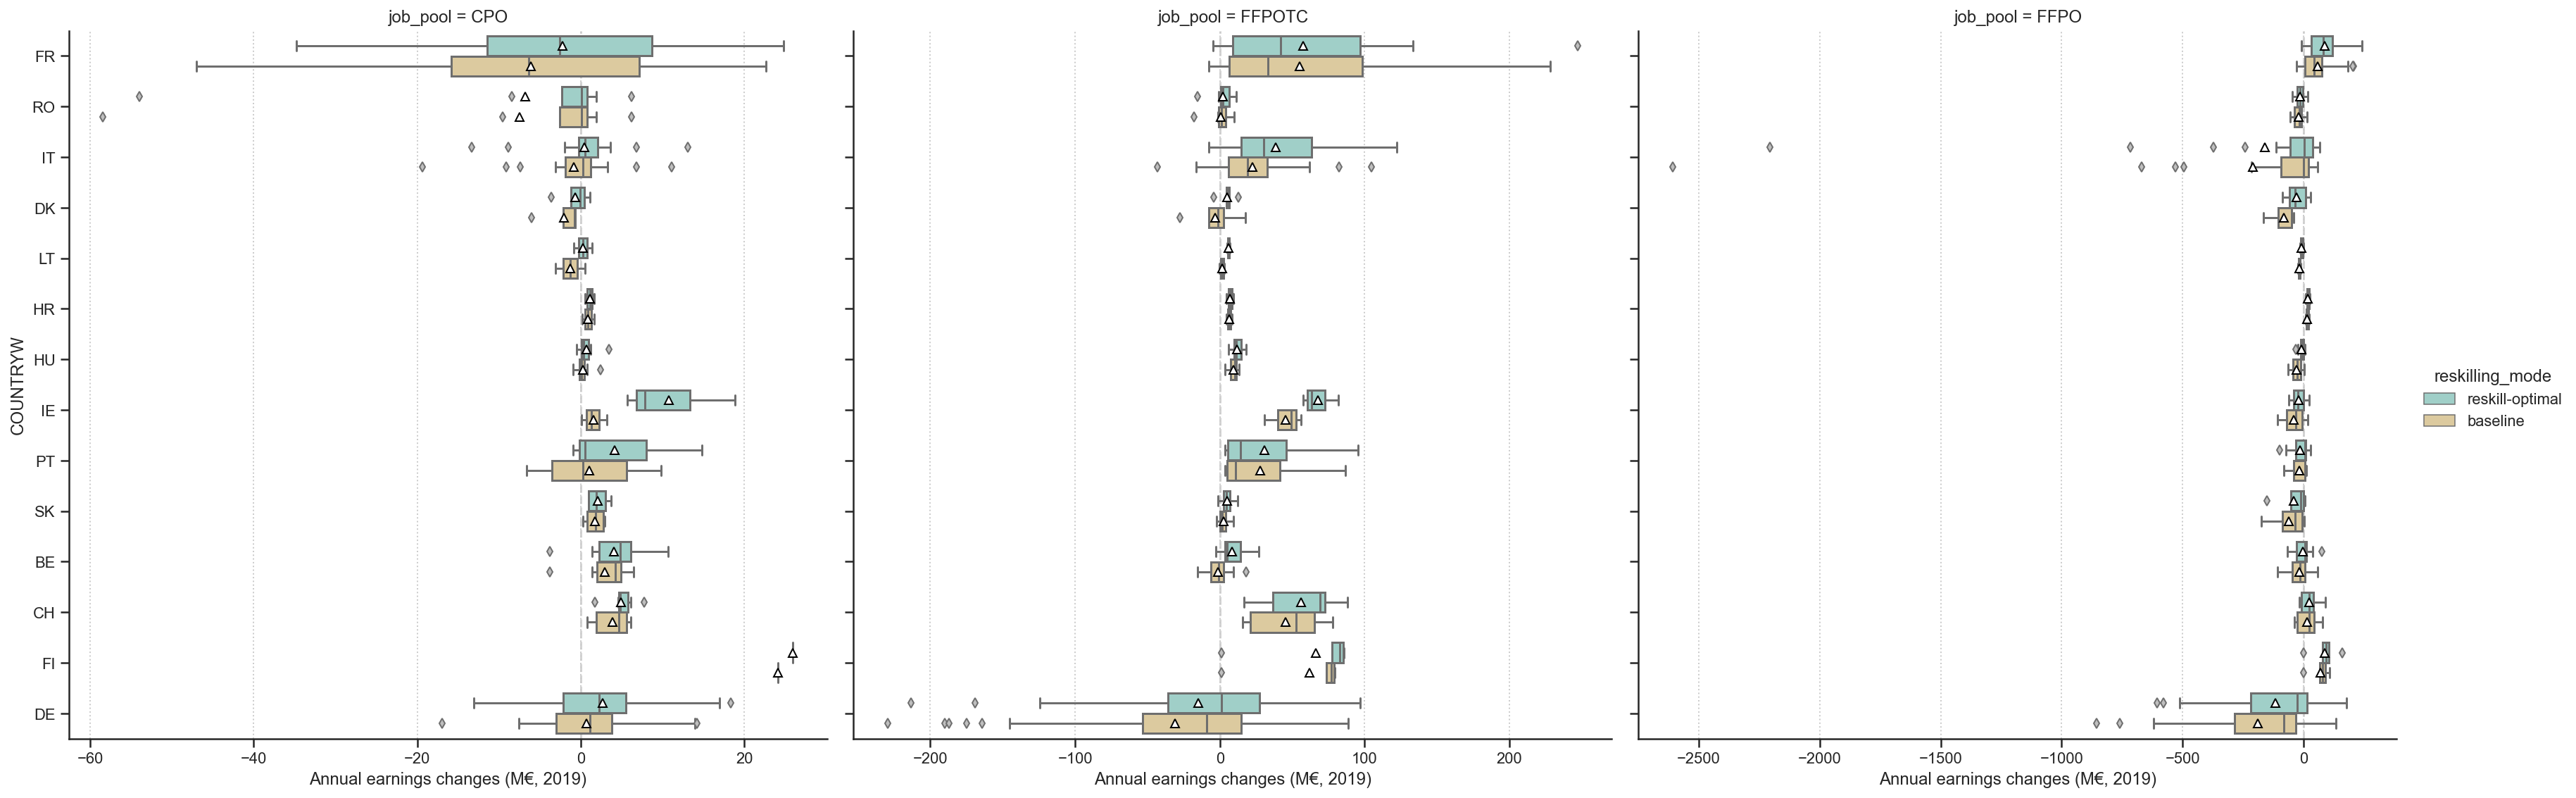

In [30]:
y = "COUNTRYW"
x = "earnings_delta_closest_switch_sum_mio"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = ["reskill-optimal", "baseline"]
sharey = True
sharex = False
kind = "box"
palette = "BrBG_r"

aggdict = {
    "n_viable_transitions": np.median,
    "earnings_delta_closest_switch_sum_mio": np.sum,
    "viability_threshold": "first",
}

df = df_regions.loc[
    (df_regions["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_regions["regional_constraint"] == "regC")
    & (~df_regions["COUNTRYW"].isin(earnings_data_missing))
]
order = (
    df.loc[
        (
            df_regions["reskilling_mode"].isin(["baseline"])
            & (df_regions["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=True)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=8,
    aspect=1,
    palette=palette,
)

# annotate vline
axes = g.axes.flatten()
for i, ax in enumerate(axes):
    ax.grid(linestyle=":", axis="x")
    ax.axvline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_11444\3120614219.py:81: RuntimeWarning: Mean of empty slice
  pos = np.nanmean(df_hue["earnings_delta_closest_switch_sum_mio"])


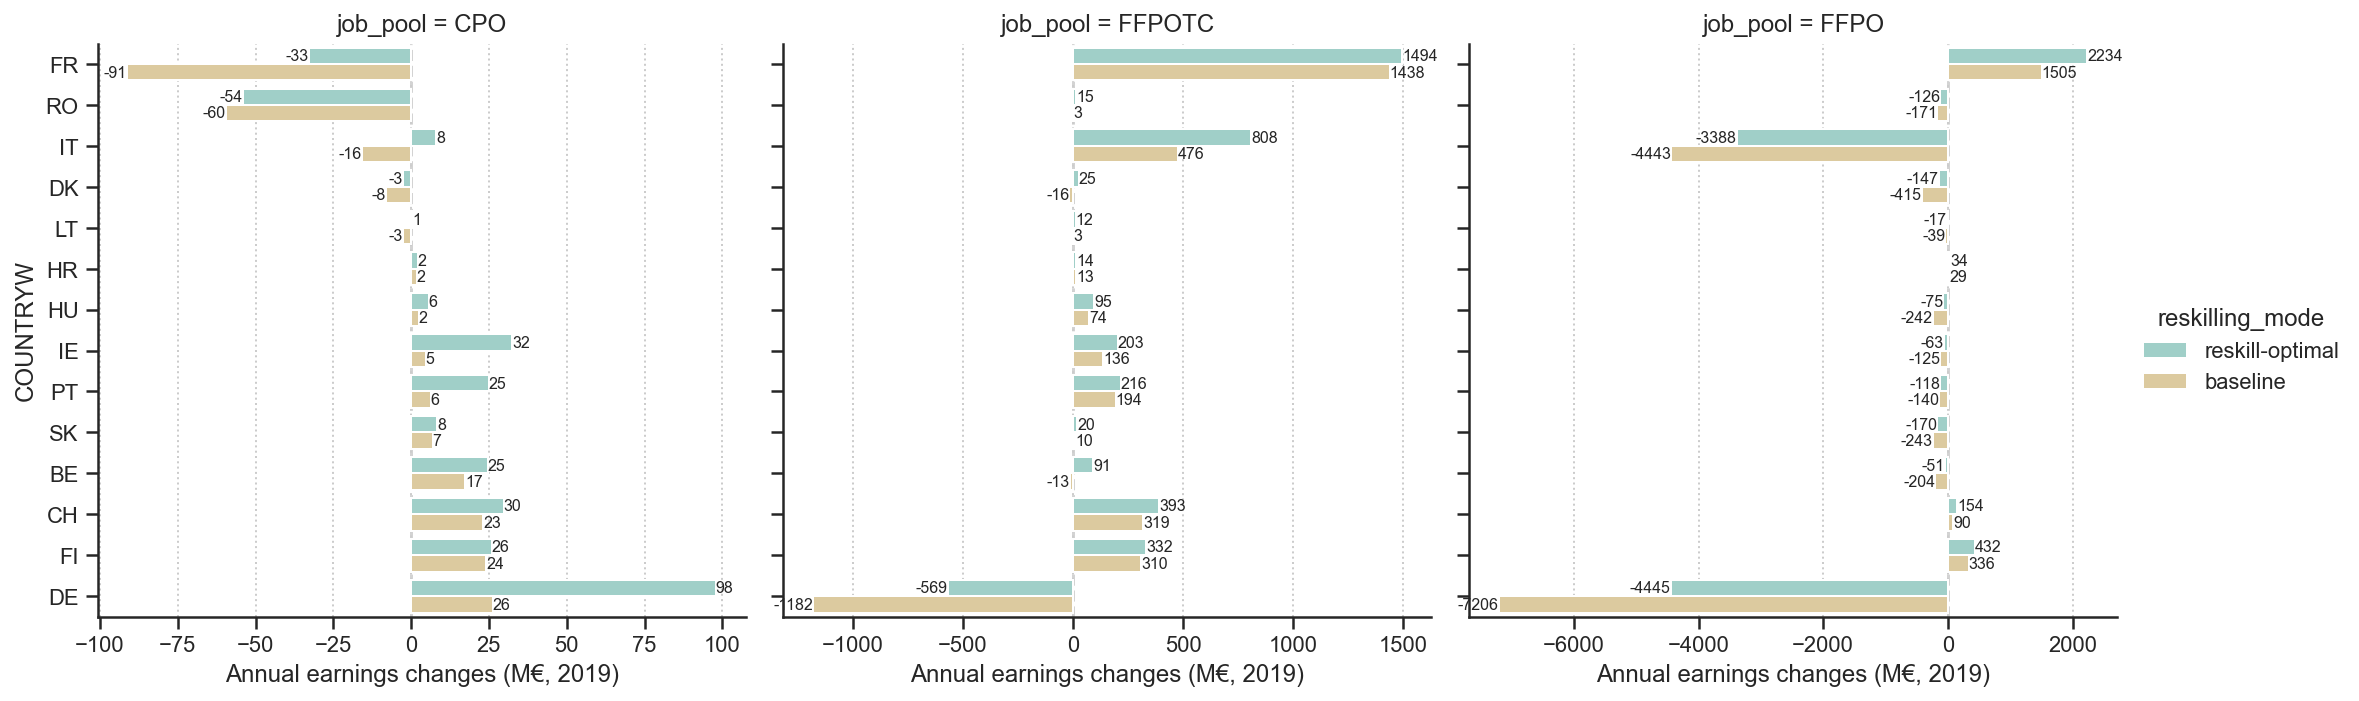

In [31]:
y = "COUNTRYW"
x = "earnings_delta_closest_switch_sum_mio"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = ["reskill-optimal", "baseline"]
sharey = True
sharex = False
kind = "bar"
palette = "BrBG_r"

aggdict = {
    "n_viable_transitions": np.median,
    "earnings_delta_closest_switch_sum_mio": np.sum,
    "viability_threshold": "first",
}

# calc order
df = df_regions.loc[
    (df_regions["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_regions["regional_constraint"] == "regC")
    & (~df_regions["COUNTRYW"].isin(earnings_data_missing))
]
order = (
    df.loc[
        (
            df_regions["reskilling_mode"].isin(["baseline"])
            & (df_regions["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=True)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    estimator=np.sum,
    ci=False,
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette=palette,
)

df_annot = df.groupby(["job_pool", "COUNTRYW", "reskilling_mode"]).agg(aggdict)
df_annot = df_annot.reindex(order, level=0).reset_index()

# annotate vline
axes = g.axes.flatten()
for i, ax in enumerate(axes):
    ax.axvline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Annual earnings changes (M€, 2019)")
    ax.grid(linestyle=":", axis="x")

    # annotate numbers (one container per hue level)
    for container in ax.containers:
        df_hue = df_annot.loc[
            (df_annot[hue] == container.get_label())
            & (df_annot["job_pool"] == col_order[i])
        ]
        ax.bar_label(
            container, labels=df_hue[x], fmt="%.0f", fontsize=8, label_type="edge"
        )
        # annotate mean
        pos = np.nanmean(df_hue["earnings_delta_closest_switch_sum_mio"])
        c = container[-1].get_facecolor()
        ax.axvline(pos, linestyle="--", color=c, label=r"$\mu$")  # , zorder=0)

        ax.text(
            pos,
            0,
            r"$\mu = {:.1f}$".format(pos),
            rotation=90,
            va="bottom",
            ha="center",
            fontsize=8,
        )

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [32]:
df_hue

,job_pool,COUNTRYW,reskilling_mode,n_viable_transitions,earnings_delta_closest_switch_sum_mio,viability_threshold
